# Topic Model Comparison — Papers vs iGEM

Joint UMAP-space comparison, density-ratio mapping, and temporal precedence analysis between papers and iGEM teams.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import cycle
from umap import UMAP

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
EMBEDS = os.path.join(ASSETS, 'embeddings')
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

In [2]:
# Load papers metadata and topics
papers = pd.read_csv(os.path.join(ASSETS, 'synbio_openalex.txt'), sep='\t')
doc_topics = pd.read_csv(os.path.join(MODELS, 'papers_doc_topics.txt'), sep='\t')
topic_names = pd.read_csv(os.path.join(MODELS, 'papers_topic_names.txt'), sep='\t')

papers = papers.merge(doc_topics, on='id', how='left')
papers = papers.merge(topic_names[['topic', 'global_name']], on='topic', how='left')
papers['cited_by_count'] = pd.to_numeric(papers['cited_by_count'], errors='coerce').fillna(0).astype(int)
papers['publication_year'] = pd.to_numeric(papers['publication_year'], errors='coerce')

# Load teams topic assignments and names
teams_doc_topics = pd.read_csv(os.path.join(MODELS, 'teams_doc_topics.txt'), sep='\t')
teams_topic_names = pd.read_csv(os.path.join(MODELS, 'teams_topic_names.txt'), sep='\t')

print(f"Papers: {len(papers):,}")
print(f"Teams assignments: {len(teams_doc_topics):,}")

Papers: 24,202
Teams assignments: 4,548


## Topic model plots — Joint UMAP space

Both papers and teams embeddings come from the same all-MiniLM-L6-v2 encoder, so projecting all documents together into one 2D manifold keeps distances directly interpretable.

In [3]:
# Load embeddings and project jointly
papers_emb = np.load(os.path.join(EMBEDS, 'papers_embeddings.npy'))
teams_emb = np.load(os.path.join(EMBEDS, 'teams_embeddings.npy'))

n_papers = len(papers_emb)
n_teams = len(teams_emb)
assert n_papers == len(doc_topics), 'Papers embeddings vs doc_topics mismatch'
assert n_teams == len(teams_doc_topics), 'Teams embeddings vs doc_topics mismatch'

all_emb = np.vstack([papers_emb, teams_emb])
umap_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=SEED,
)
all_xy = umap_2d.fit_transform(all_emb)

papers_xy = all_xy[:n_papers]
teams_xy = all_xy[n_papers:]

print(f"Joint projection: {all_xy.shape} (papers {papers_xy.shape}, teams {teams_xy.shape})")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Joint projection: (28750, 2) (papers (24202, 2), teams (4548, 2))


In [4]:
# Build plotting dataframes
palette = [
    '#f00f15', '#2270e7', '#e5e510', '#ff8103', '#4f3dd1',
    '#26cc3a', '#ec058e', '#9cb8c2', '#fffdd0', '#b40e68',
    '#5afb5a', '#beaed4', '#fdc086', '#99fdff', '#c430ff',
    '#e4dbe0', '#bf5b17', '#666666',
]

def build_plot_df(xy, dt, tn, id_col='id', size_col=None, size_df=None):
    df = dt.copy()
    df['x'] = xy[:, 0]
    df['y'] = xy[:, 1]
    df = df.merge(tn[['topic', 'global_name']], on='topic', how='left')
    if size_col and size_df is not None:
        df = df.merge(
            size_df[[id_col, size_col]].drop_duplicates(id_col),
            on=id_col,
            how='left',
        )
    topics_sorted = sorted(df.loc[df['topic'] >= 0, 'topic'].unique())
    cc = cycle(palette)
    cmap = {t: next(cc) for t in topics_sorted}
    cmap[-1] = '#d3d3d3'
    df['color'] = df['topic'].map(cmap)
    return df, topics_sorted

df_papers, papers_topics = build_plot_df(
    papers_xy, doc_topics, topic_names,
    id_col='id', size_col='cited_by_count', size_df=papers,
)
df_teams, teams_topics = build_plot_df(
    teams_xy, teams_doc_topics, teams_topic_names,
    id_col='UT',
)

_pad = 1.5
XLIM = (all_xy[:, 0].min() - _pad, all_xy[:, 0].max() + _pad)
YLIM = (all_xy[:, 1].min() - _pad, all_xy[:, 1].max() + _pad)

print(f"Papers: {len(df_papers):,} pts, {len(papers_topics)} topics")
print(f"Teams:  {len(df_teams):,} pts, {len(teams_topics)} topics")
print(f"Shared axis limits: x={XLIM}, y={YLIM}")

Papers: 24,202 pts, 263 topics
Teams:  4,548 pts, 161 topics
Shared axis limits: x=(np.float32(-6.5288377), np.float32(19.218245)), y=(np.float32(-2.0912228), np.float32(16.082216))


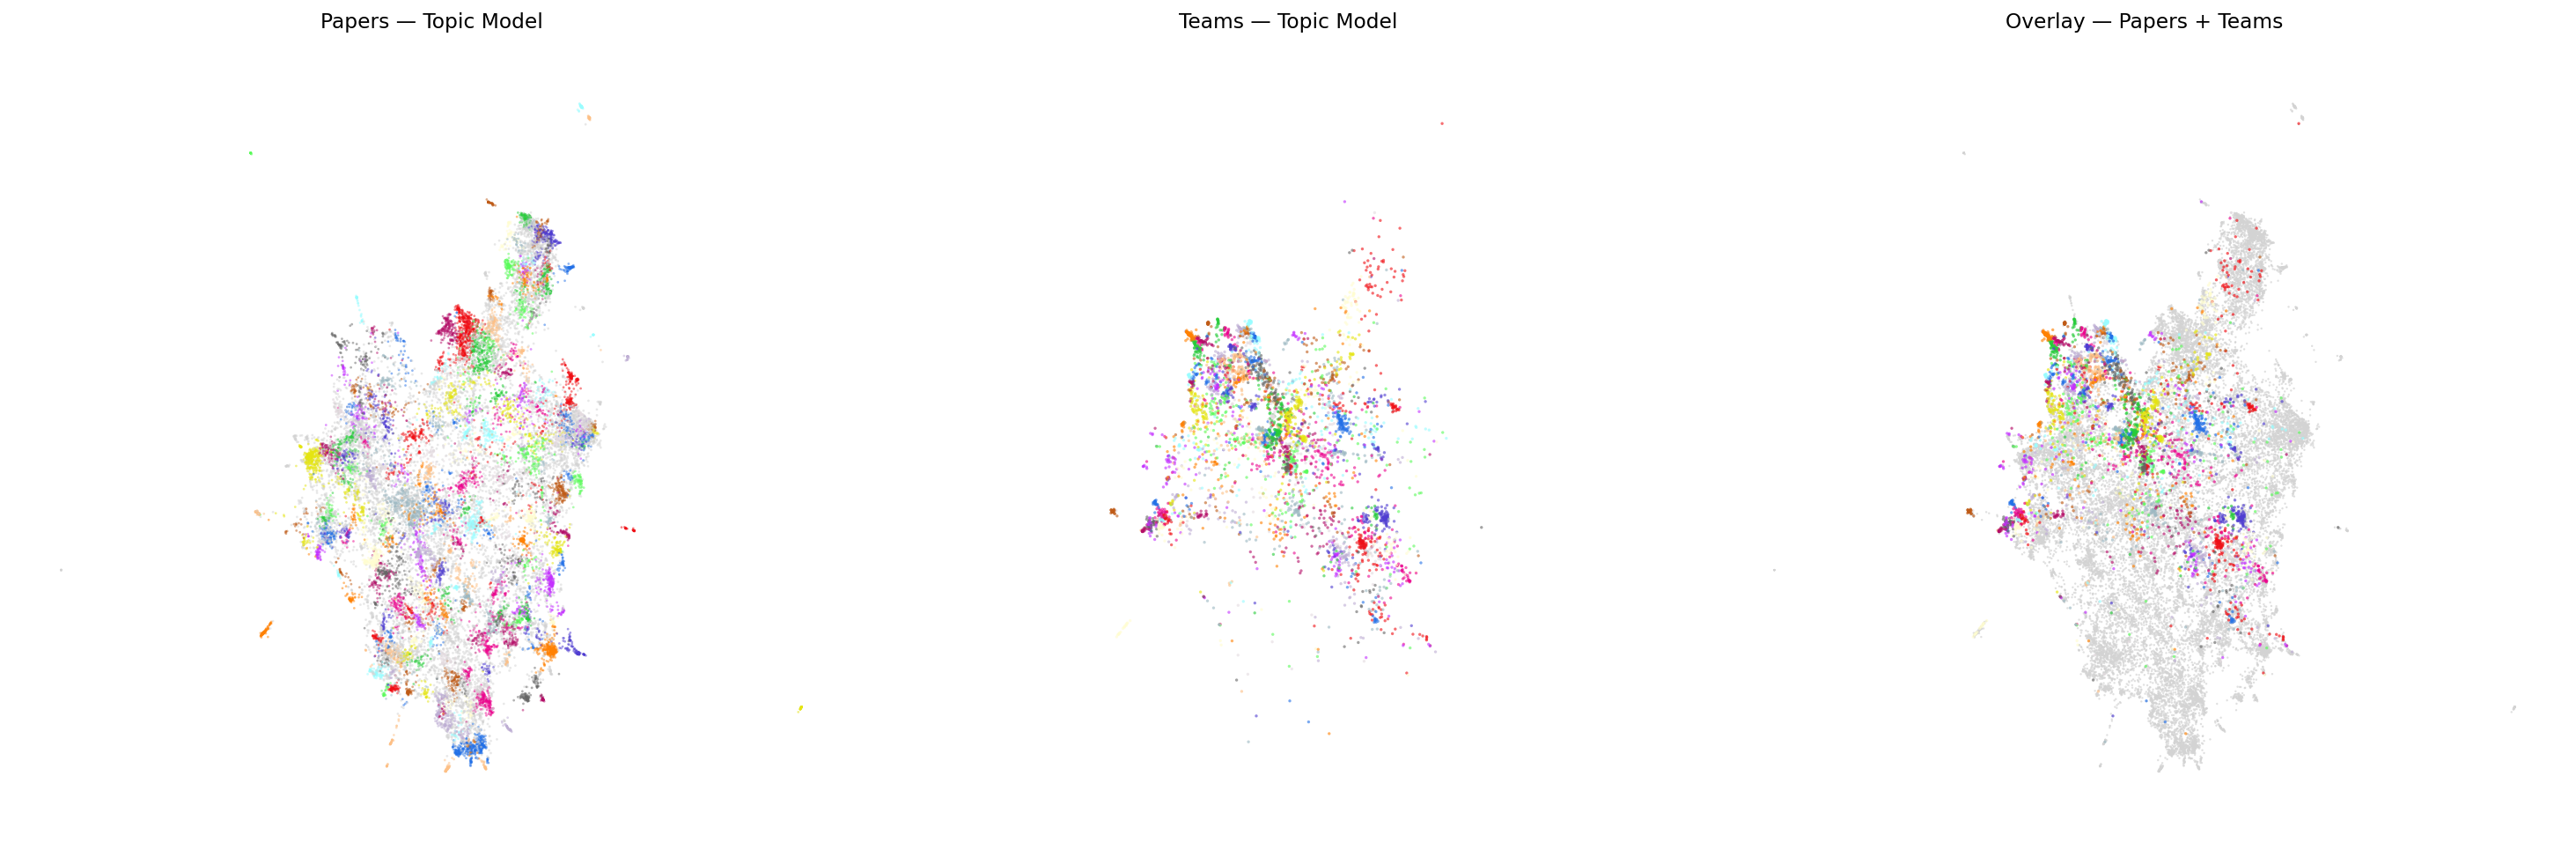

In [5]:
# Papers and teams topic maps + overlay
fig, axes = plt.subplots(1, 3, figsize=(21, 7), dpi=140)

axes[0].scatter(df_papers['x'], df_papers['y'], c=df_papers['color'], s=2, alpha=0.5, edgecolors='none')
axes[0].set_title('Papers — Topic Model')

axes[1].scatter(df_teams['x'], df_teams['y'], c=df_teams['color'], s=3, alpha=0.6, edgecolors='none')
axes[1].set_title('Teams — Topic Model')

axes[2].scatter(df_papers['x'], df_papers['y'], c='#d3d3d3', s=1.5, alpha=0.7, edgecolors='none')
axes[2].scatter(df_teams['x'], df_teams['y'], c=df_teams['color'], s=3, alpha=0.65, edgecolors='none')
axes[2].set_title('Overlay — Papers + Teams')

for ax in axes:
    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Density ratio map — Papers vs Teams

We estimate kernel density for each corpus on the same 2D grid and compute `log2(teams_density / papers_density)`.

In [6]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

kde_papers = gaussian_kde(papers_xy.T, bw_method=0.15)
kde_teams = gaussian_kde(teams_xy.T, bw_method=0.15)

x_min, x_max = XLIM
y_min, y_max = YLIM
grid_res = 300
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, grid_res),
    np.linspace(y_min, y_max, grid_res),
)
grid_pts = np.vstack([xx.ravel(), yy.ravel()])

p = kde_papers(grid_pts)
q = kde_teams(grid_pts)
p /= p.sum()
q /= q.sum()

eps = 1e-12
ratio = np.log2((q + eps) / (p + eps))
ratio_grid = ratio.reshape(xx.shape)

vmax = np.percentile(np.abs(ratio_grid), 98)
ratio_grid = np.clip(ratio_grid, -vmax, vmax)

p_grid = p.reshape(xx.shape)
q_grid = q.reshape(xx.shape)
combined = p_grid + q_grid
alpha_grid = combined / np.percentile(combined, 95)
alpha_grid = np.clip(alpha_grid, 0, 1)
alpha_grid = gaussian_filter(alpha_grid, sigma=3)

print(f"Grid: {grid_res}x{grid_res}, ratio range clipped to +/-{vmax:.1f}")

Grid: 300x300, ratio range clipped to +/-19.4


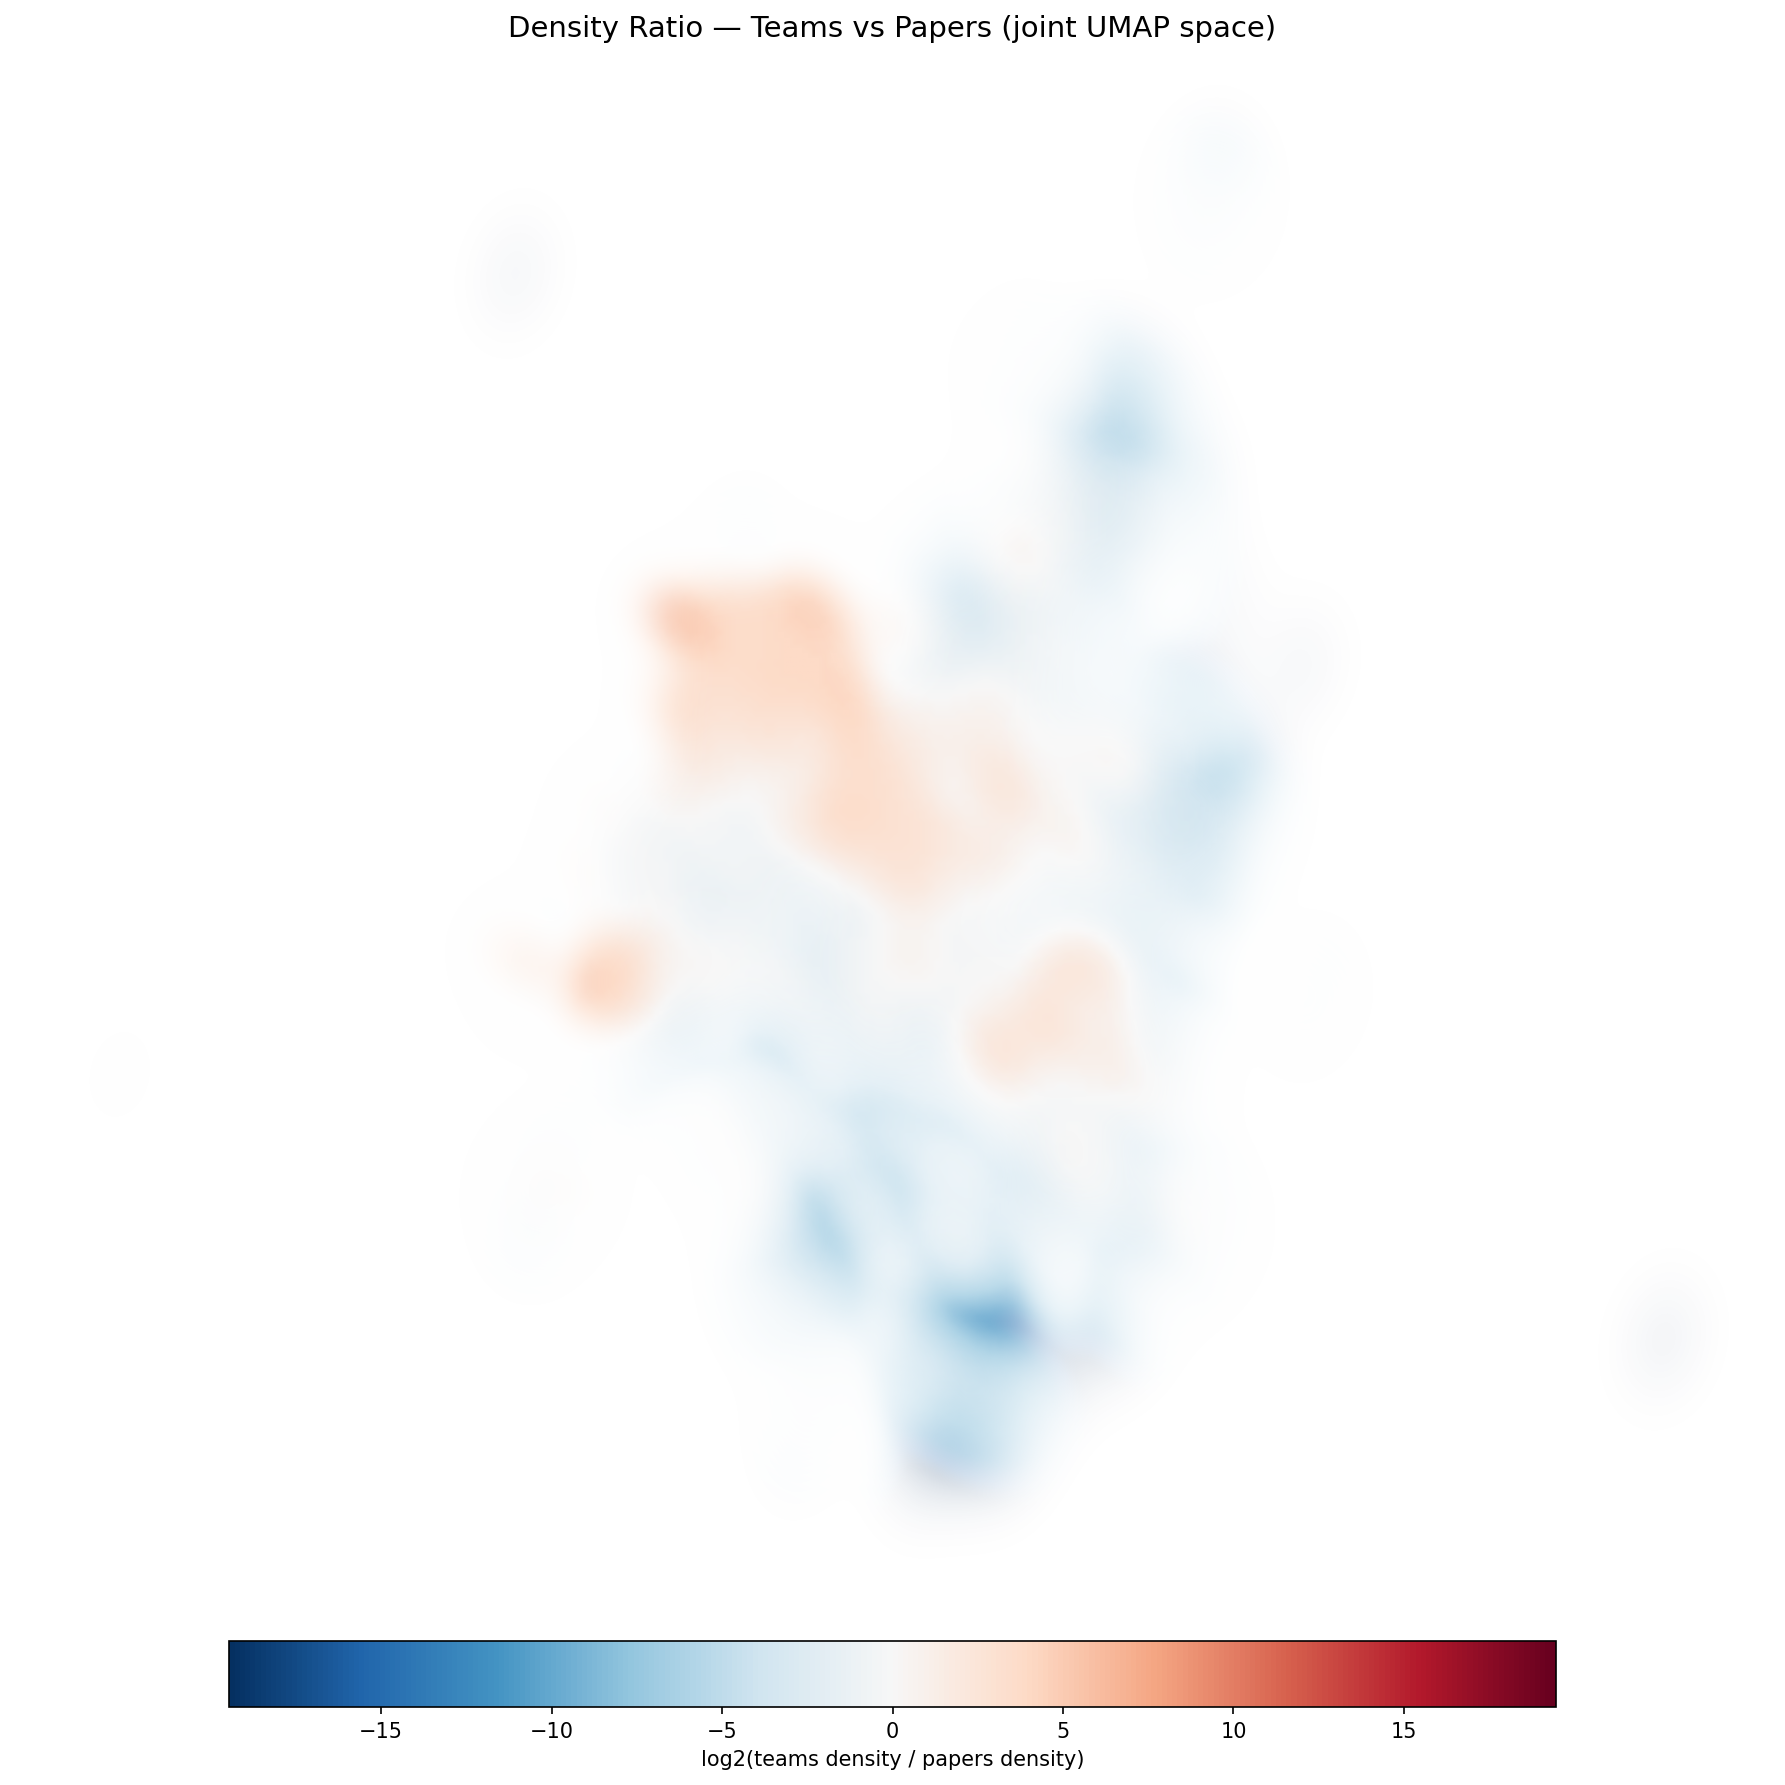

In [7]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
cmap = plt.cm.RdBu_r
rgba = cmap(norm(ratio_grid))
rgba[..., 3] = alpha_grid

ax.imshow(
    rgba,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    aspect='auto',
    interpolation='bilinear',
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.04, pad=0.03)
cbar.set_label('log2(teams density / papers density)', fontsize=10)

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_title('Density Ratio — Teams vs Papers (joint UMAP space)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Quantitative overlap metrics + temporal precedence
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

x_vals = np.linspace(*XLIM, grid_res)
y_vals = np.linspace(*YLIM, grid_res)
ratio_filled = np.ma.filled(ratio_grid, fill_value=np.nan)
ratio_interp = RegularGridInterpolator(
    (y_vals, x_vals), ratio_filled,
    method='linear', bounds_error=False, fill_value=np.nan,
)

_df_p = df_papers[df_papers['topic'] >= 0].copy()
_df_p = _df_p.merge(papers[['id', 'publication_year']], on='id', how='left')

papers_ctr = _df_p.groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'),
    n_docs=('x', 'size'),
    avg_year=('publication_year', 'mean'),
    global_name=('global_name', 'first'),
).reset_index()
papers_ctr['log2_ratio'] = ratio_interp(
    np.column_stack([papers_ctr['cy'].values, papers_ctr['cx'].values])
)

teams_raw = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t', usecols=['UT', 'Year_y'])
teams_raw['Year_y'] = pd.to_numeric(teams_raw['Year_y'], errors='coerce')

_df_t = df_teams[df_teams['topic'] >= 0].copy()
_df_t = _df_t.merge(teams_raw, on='UT', how='left')

teams_ctr = _df_t.groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'),
    n_docs=('x', 'size'),
    avg_year=('Year_y', 'mean'),
    global_name=('global_name', 'first'),
).reset_index()
teams_ctr['log2_ratio'] = ratio_interp(
    np.column_stack([teams_ctr['cy'].values, teams_ctr['cx'].values])
)

def classify(r):
    if pd.isna(r):
        return 'unmapped'
    if r > 1:
        return 'teams-dominant'
    if r < -1:
        return 'papers-only'
    return 'overlap'

papers_ctr['zone'] = papers_ctr['log2_ratio'].apply(classify)
teams_ctr['zone'] = teams_ctr['log2_ratio'].apply(classify)

print('=== Papers topics by zone ===')
print(papers_ctr['zone'].value_counts().to_string())
print('\n=== Teams topics by zone ===')
print(teams_ctr['zone'].value_counts().to_string())

teams_tree = cKDTree(teams_xy)
_df_t_full = df_teams.merge(teams_raw, on='UT', how='left')
precedence = []
overlap_topics = papers_ctr[papers_ctr['zone'] == 'overlap']

for _, row in overlap_topics.iterrows():
    topic_pts = _df_p.loc[_df_p['topic'] == row['topic'], ['x', 'y']].values
    dists = np.sqrt((topic_pts[:, 0] - row['cx']) ** 2 + (topic_pts[:, 1] - row['cy']) ** 2)
    radius = np.median(dists) * 1.5

    nearby_idx = teams_tree.query_ball_point([row['cx'], row['cy']], r=radius)
    nearby_years = _df_t_full.iloc[nearby_idx]['Year_y'].dropna()
    if len(nearby_years) < 3:
        continue

    delta = nearby_years.mean() - row['avg_year']
    precedence.append({
        'topic': row['topic'],
        'global_name': row['global_name'],
        'n_papers': row['n_docs'],
        'n_nearby_teams': len(nearby_idx),
        'avg_year_papers': round(row['avg_year'], 1),
        'avg_year_teams': round(nearby_years.mean(), 1),
        'delta_years': round(delta, 2),
    })

df_prec = pd.DataFrame(precedence).sort_values('delta_years')
df_igem_preceded = df_prec[df_prec['delta_years'] < 0].copy()
df_lit_preceded = df_prec[df_prec['delta_years'] > 0].copy()

df_igem_preceded.to_csv(os.path.join(REPORTS, 'igem_preceded.tsv'), sep='\t', index=False)
df_lit_preceded.to_csv(os.path.join(REPORTS, 'literature_preceded.tsv'), sep='\t', index=False)

print(f"Saved to {REPORTS}/")
print(f"  igem_preceded.tsv ({len(df_igem_preceded)} rows)")
print(f"  literature_preceded.tsv ({len(df_lit_preceded)} rows)")

cols = ['global_name', 'n_papers', 'n_nearby_teams', 'avg_year_papers', 'avg_year_teams', 'delta_years']
print('\nTop iGEM-preceded topics:')
print(df_igem_preceded.head(10)[cols].to_string(index=False))
print('\nTop literature-preceded topics:')
print(df_lit_preceded.tail(10)[cols].to_string(index=False))

=== Papers topics by zone ===
zone
papers-only       148
overlap            83
teams-dominant     32

=== Teams topics by zone ===
zone
teams-dominant    115
overlap            44
papers-only         2
Saved to ../assets/reports/
  igem_preceded.tsv (34 rows)
  literature_preceded.tsv (36 rows)

Top iGEM-preceded topics:
                            global_name  n_papers  n_nearby_teams  avg_year_papers  avg_year_teams  delta_years
                AI in Synthetic Biology        27              21           2022.8          2016.9        -5.96
          Microbial Chassis Development        25               9           2018.8          2014.3        -4.47
            CRISPR in Synthetic Biology        32              35           2021.3          2016.9        -4.46
    AI-Driven Imaging and Data Analysis        44               7           2019.1          2014.7        -4.42
           Microalgal Synthetic Biology        27               5           2020.3          2016.2        -4.06
     